# EXP5 - MVE Analysis

In [ ]:
# Cell 1: imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pymannkendall as mk
from pathlib import Path

from src.config import (
    PROCESSED_DATA_DIR,
    OUTPUT_DATA_DIR,
    OUTPUT_STATIC_ATTR,
    DATA_START_YEAR,
    DATA_END_YEAR,
    TRAIN_END_YEAR,
)

sns.set_theme(style='whitegrid', context='notebook')

# Analysis parameters
WINDOW = 15                       
WINDOWS_ROBUST = [10, 20]
N_MEMBERS = 10
N_BOOTSTRAP = 1000
RNG = np.random.default_rng(42)

# Input paths
TOPOGRAPH_LSTM = OUTPUT_DATA_DIR / 'topographic_lstm'
OBS_PATH = PROCESSED_DATA_DIR / 'combined_streamflow.csv'
STATIC_PATH = OUTPUT_STATIC_ATTR

# Output paths
MVE_RESULTS_DIR = OUTPUT_DATA_DIR / 'results_MVE'
FIG_DIR = MVE_RESULTS_DIR / 'figures'

# FIG_DIR.mkdir(parents=True, exist_ok=True)

## Math Foundation: decomposition and notation

**Setup**

- $y_t$ — observed flow at time $t$
- $f_m(x_t),\ m = 1,\dots,M,\ M = 10$ — frozen ensemble member predictions (point predictors)
- $\hat\mu_t = \frac{1}{M}\sum_{m=1}^{M} f_m(x_t)$ — ensemble mean
- $r_t = y_t - \hat\mu_t$ — residual
- $\hat b(x) = \mathbb{E}[\,r \mid x\,]$ — conditional bias (binned/smoothed mean residual, Part 1)

**Law of total variance** (the quantity being decomposed)

$$
\underbrace{\mathrm{Var}(y \mid x)}_{\text{total}}
= \underbrace{\mathbb{E}_{\theta}\!\big[\mathrm{Var}(y \mid x, \theta)\big]}_{\text{aleatoric},\ \sigma_a^2(x)}
+ \underbrace{\mathrm{Var}_{\theta}\!\big[\mathbb{E}(y \mid x, \theta)\big]}_{\text{epistemic},\ \sigma_e^2(x)}
$$

**Empirical estimators (point-predictor ensemble)**

Epistemic — between-member variance, available pointwise:

$$
\hat\sigma_e^2(x_t) = \frac{1}{M-1}\sum_{m=1}^{M}\big(f_m(x_t) - \hat\mu_t\big)^2
$$

Aleatoric — conditional residual variance, the head's target:

$$
\hat\sigma_a^2(x) = \mathrm{Var}\big[\,y - \hat\mu \mid x\,\big]
= \underbrace{\mathbb{E}[\,r^2 \mid x\,]}_{\mathrm{MSR}(x)} - \hat b(x)^2
$$

estimated by binning/smoothing over similar $x$ (flow percentile or regime).

Total predictive variance:

$$
\hat\sigma_{\text{tot}}^2(x) = \hat\sigma_a^2(x) + \hat\sigma_e^2(x)
$$

Variance head (next stage):

$$
\hat\sigma_{\text{head}}^2(x_t) \approx \sigma_a^2(x_t)
$$

a smooth pointwise function fit to the empirical $\hat\sigma_a^2$.

**Notes**

1. **Aleatoric is the residual _variance_, not the MSR.** Since $\mathrm{MSR}(x) = \sigma_a^2(x) + b(x)^2$, raw MSR double-counts squared bias — hence the Part 1 gate must clear first. Where $\hat b(x) \approx 0$, $\hat\sigma_a^2(x) \approx \widehat{\mathrm{MSR}}(x)$.
2. **Epistemic is added, never subtracted.** Total $= \sigma_a^2 + \sigma_e^2$. Aleatoric comes from the mean's residual variance; epistemic is layered on top for the total.
3. **Pointwise vs conditional.** $\hat\sigma_e^2$ exists at every $t$ (all $M$ members are present); $\hat\sigma_a^2$ needs many residuals, so it is binned/windowed, not per-timestep. This is why epistemic anchors the AR / heat-dome events pointwise while aleatoric-at-events waits for the head.
4. **Point predictors, so the head is necessary.** Members emit no per-member variance, so the LTV aleatoric term $\mathbb{E}_\theta[\mathrm{Var}(y\mid x,\theta)]$ is empty: the ensemble gives $\hat\sigma_e^2$ directly but cannot give $\sigma_a^2$, which is recovered from residuals here and modelled by the head next.
5. **Conventions.** Use $M-1$ (ten members is a small sample); define $y, \hat\mu, r$ in the Part 1 transform space, and transform back explicitly if reporting native-flow variance, since the split is not invariant to the log/NSE\* mapping.

## Part 1 - Mean/residuals analysis from Frozen Mean head

Notes about this analysis:

We want to compare the ensemble mean ($\hat\mu$) against the observed flow $y$. We then are hoping to extract $\hat\sigma$ from a variance head post-hoc. 

## Bias:
### Residuals vs Fitted plot: With a mean estimate line and spread band
Check heteroscedasticity of predictions.

### Binned bias and spread by flow percentile: mean residual with confidence interval per bin, and residual standard deviation per bin
Shows whether bias concentrates in the high- and low-flow tails and how spread scales with flow.

### Predicted vs observed scatter, linear and log panels, with the 1:1 line 
The cloud falling below 1:1 at the top end is peak under-prediction; the log panel exposes low-flow behavior the linear panel hides.

269 stations x 15706 days | 3,763,874 valid (station,day) residuals


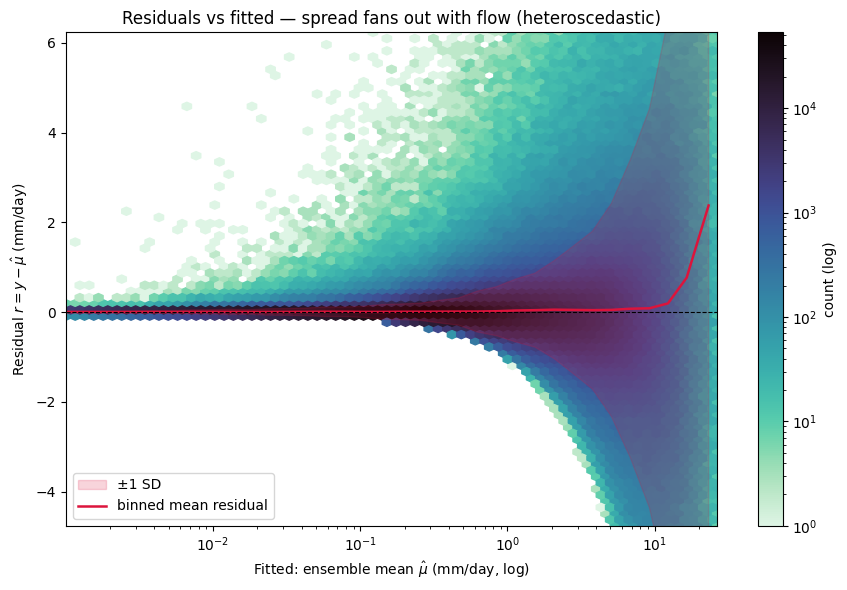

In [16]:
# Cell 6: Residuals vs fitted (heteroscedasticity check)
# --- Load once for all of Part 1 (no prior load cell; cells 7-8, 10-11 reuse these) ---
# Transform space = physical mm/day (sim CSVs are mm/day; obs is m3/s -> mm/day via
# 86.4/basin_area_km2, the documented 2026-05-19 convention). No log transform.

# Ensemble mean mu_hat = (1/M) sum_m f_m  (math cell, mu_hat)
_members = [
    pd.read_csv(TOPOGRAPH_LSTM / f'topographic_lstm_preds_member_{m}.csv',
                index_col=0, parse_dates=True)
    for m in range(N_MEMBERS)
]
assert all(d.index.equals(_members[0].index) for d in _members), 'member dates differ'
assert all(d.columns.equals(_members[0].columns) for d in _members), 'member stations differ'
mu = pd.DataFrame(np.stack([d.values for d in _members]).mean(axis=0),
                  index=_members[0].index, columns=_members[0].columns)

# Observed flow -> mm/day
obs_raw = pd.read_csv(OBS_PATH, index_col='Date', parse_dates=True)          # m3/s
area = pd.read_csv(STATIC_PATH).set_index('station_id')['basin_area_km2']     # km2

# Align on stations and dates common to all three
stations = sorted(set(obs_raw.columns) & set(mu.columns) & set(area.index))
dates = obs_raw.index.intersection(mu.index)
obs_mm = obs_raw.loc[dates, stations].mul(86.4 / area[stations], axis=1)      # mm/day
mu = mu.loc[dates, stations]
resid = obs_mm - mu                                                           # r = y - mu_hat
print(f'{len(stations)} stations x {len(dates)} days | '
      f'{np.isfinite(resid.values).sum():,} valid (station,day) residuals')

# Flatten and drop NaNs (pooled across all basins; see caveat below)
fit_flat = mu.values.ravel()
res_flat = resid.values.ravel()
obs_flat = obs_mm.values.ravel()
mask = np.isfinite(fit_flat) & np.isfinite(res_flat)

# CAVEAT: pooled across basins, so fitted flow mixes regime with basin scale (large
# basins -> larger mm/day). Cell 7 bins by *within-basin* percentile to isolate regime;
# here a LOG fitted-axis spreads the order-of-magnitude flow range so the spread fan is
# legible (the linear pooled view crushes 99% of points into the low-flow corner).

# Binned mean residual +/- 1 SD over LOG-spaced fitted bins (positive fitted only)
pos = mask & (fit_flat > 0)
fp, rp = fit_flat[pos], res_flat[pos]
edges = np.geomspace(np.quantile(fp, 0.005), np.quantile(fp, 0.999), 35)
bidx = np.clip(np.digitize(fp, edges[1:-1]), 0, len(edges) - 2)
ctr, m_r, sd_r = [], [], []
for b in range(len(edges) - 1):
    sel = bidx == b
    if sel.sum() < 50:
        continue
    ctr.append(np.median(fp[sel]))
    m_r.append(rp[sel].mean())
    sd_r.append(rp[sel].std())
ctr, m_r, sd_r = map(np.asarray, (ctr, m_r, sd_r))

fig, ax = plt.subplots(figsize=(9, 6))
xlim = (np.quantile(fp, 0.005), np.quantile(fp, 0.999))
ylim = np.quantile(rp, [0.005, 0.995])
hb = ax.hexbin(fp, rp, xscale='log', gridsize=70, bins='log', cmap='mako_r', mincnt=1,
               extent=(np.log10(xlim[0]), np.log10(xlim[1]), ylim[0], ylim[1]))
ax.fill_between(ctr, m_r - sd_r, m_r + sd_r, color='crimson', alpha=0.18, label='±1 SD')
ax.plot(ctr, m_r, color='crimson', lw=1.8, label='binned mean residual')
ax.axhline(0, ls='--', c='k', lw=0.8)
ax.set(xscale='log', xlim=xlim, ylim=tuple(ylim),
       xlabel='Fitted: ensemble mean $\\hat\\mu$ (mm/day, log)',
       ylabel='Residual $r = y - \\hat\\mu$ (mm/day)',
       title='Residuals vs fitted — spread fans out with flow (heteroscedastic)')
fig.colorbar(hb, ax=ax, label='count (log)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


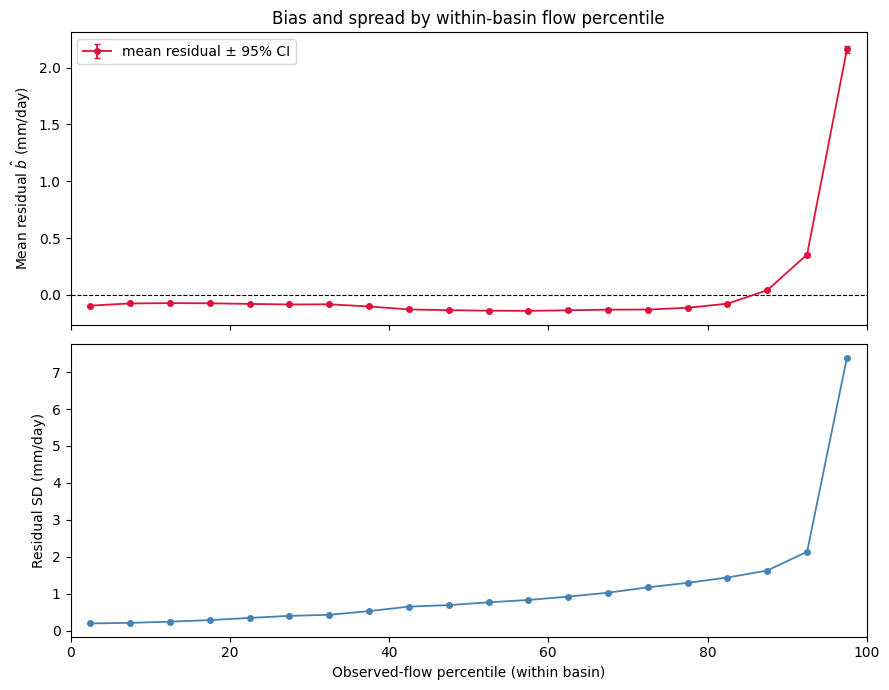

In [12]:
# Cell 7: Binned bias and spread by flow percentile
# Bin by WITHIN-BASIN observed-flow percentile (rank pct per station), so a bin is a
# flow *regime* ("each basin's top 5%"), not a basin-size artifact (cf. Cell 6 caveat).
pct = obs_mm.rank(pct=True)                       # per-station percentile across time
pct_flat = pct.values.ravel()
m2 = mask & np.isfinite(pct_flat)

NB = 20
bidx = np.clip((pct_flat[m2] * NB).astype(int), 0, NB - 1)
r = res_flat[m2]
centers = (np.arange(NB) + 0.5) / NB * 100        # bin center as percentile
mean_r = np.array([r[bidx == b].mean() for b in range(NB)])
std_r  = np.array([r[bidx == b].std()  for b in range(NB)])
n_b    = np.array([(bidx == b).sum()   for b in range(NB)])
ci = 1.96 * std_r / np.sqrt(n_b)                  # 95% CI on the bin mean

# CAVEAT: this CI assumes iid residuals. They are autocorrelated (see ACF cell) and
# spatially correlated across basins, so effective n << n_b and the CI is anti-
# conservative (here also visually tiny given n_b ~ 1e5). Read it as indicative, not
# calibrated; the std_r panel below is the substantive "how spread scales with flow".

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.axhline(0, ls='--', c='k', lw=0.8)
ax1.errorbar(centers, mean_r, yerr=ci, fmt='o-', color='crimson', ms=4,
             capsize=2, lw=1.3, label='mean residual ± 95% CI')
ax1.set(ylabel='Mean residual $\\hat b$ (mm/day)',
        title='Bias and spread by within-basin flow percentile')
ax1.legend(loc='best')

ax2.plot(centers, std_r, 'o-', color='steelblue', ms=4, lw=1.3)
ax2.set(xlabel='Observed-flow percentile (within basin)',
        ylabel='Residual SD (mm/day)', xlim=(0, 100))
plt.tight_layout()
plt.show()


Predicted <= 0 (dropped from log panel): 33,708 (0.90% of valid pairs)


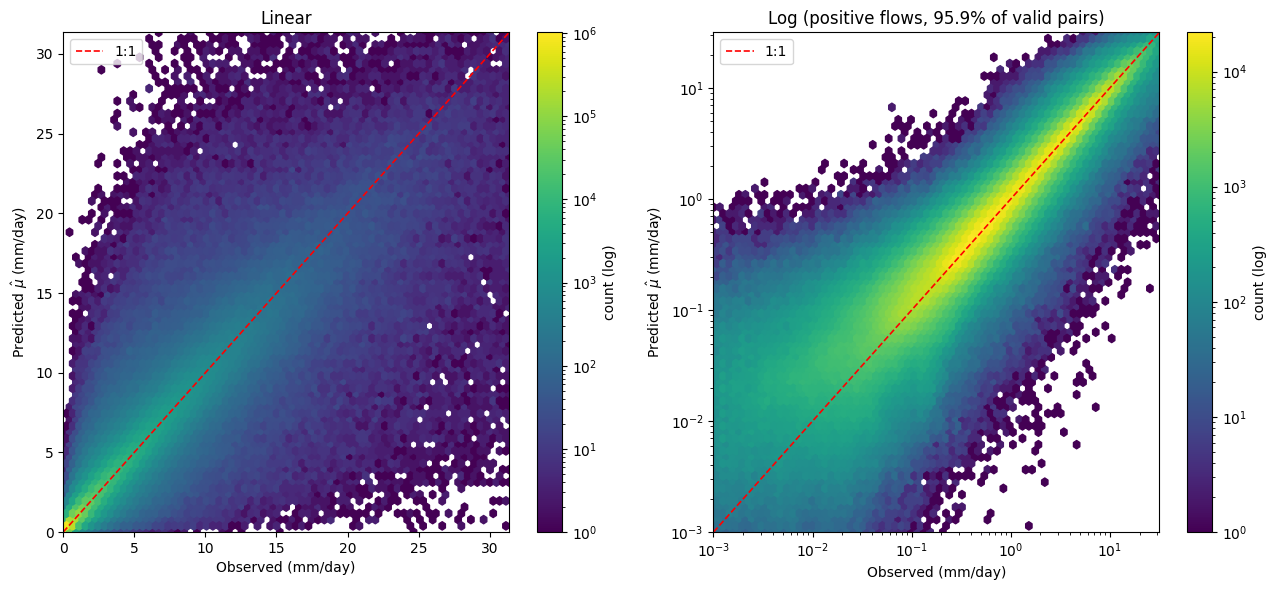

In [13]:
# Cell 8: Predicted vs observed scatter (linear + log), with 1:1 line
# x = observed, y = predicted (ensemble mean). Points below 1:1 at high obs = peak
# under-prediction. Log panel exposes low-flow behavior the linear panel compresses.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6))

# --- Linear panel ---
hi = np.quantile(np.r_[obs_flat[mask], fit_flat[mask]], 0.999)
hbL = axL.hexbin(obs_flat[mask], fit_flat[mask], gridsize=70, bins='log',
                 cmap='viridis', mincnt=1, extent=(0, hi, 0, hi))
axL.plot([0, hi], [0, hi], 'r--', lw=1.2, label='1:1')
axL.set(xlim=(0, hi), ylim=(0, hi), xlabel='Observed (mm/day)',
        ylabel='Predicted $\\hat\\mu$ (mm/day)', title='Linear')
axL.legend(loc='upper left')
fig.colorbar(hbL, ax=axL, label='count (log)')

# --- Log panel (positive flows only; sim can be slightly negative) ---
pos = mask & (obs_flat > 0) & (fit_flat > 0)
lo = max(np.quantile(obs_flat[pos], 0.001), 1e-3)
hir = np.quantile(np.r_[obs_flat[pos], fit_flat[pos]], 0.999)
hbR = axR.hexbin(obs_flat[pos], fit_flat[pos], xscale='log', yscale='log',
                 gridsize=70, bins='log', cmap='viridis', mincnt=1,
                 extent=(np.log10(lo), np.log10(hir), np.log10(lo), np.log10(hir)))
axR.plot([lo, hir], [lo, hir], 'r--', lw=1.2, label='1:1')
axR.set(xlim=(lo, hir), ylim=(lo, hir), xlabel='Observed (mm/day)',
        ylabel='Predicted $\\hat\\mu$ (mm/day)',
        title=f'Log (positive flows, {pos.sum() / mask.sum():.1%} of valid pairs)')
axR.legend(loc='upper left')
fig.colorbar(hbR, ax=axR, label='count (log)')

n_neg = int((mask & (fit_flat <= 0)).sum())
print(f'Predicted <= 0 (dropped from log panel): {n_neg:,} '
      f'({n_neg / mask.sum():.2%} of valid pairs)')
plt.tight_layout()
plt.show()


## Residual Structures: 

### Residual distributions — histogram with a Normal overlay plus a Normal QQ-plot, split by flow regime (high-flow residuals separately from low-flow)
Symmetric and Gaussian means a plain MVE head will dom skew or heavy tails, especially if regime-dependent. Otherwise tread carefully.

### Residual ACF - with a residual time-series strip for a representative window. 
Leftover autocorrelation means the mean missed some dynamics and that residuals aren't iid.

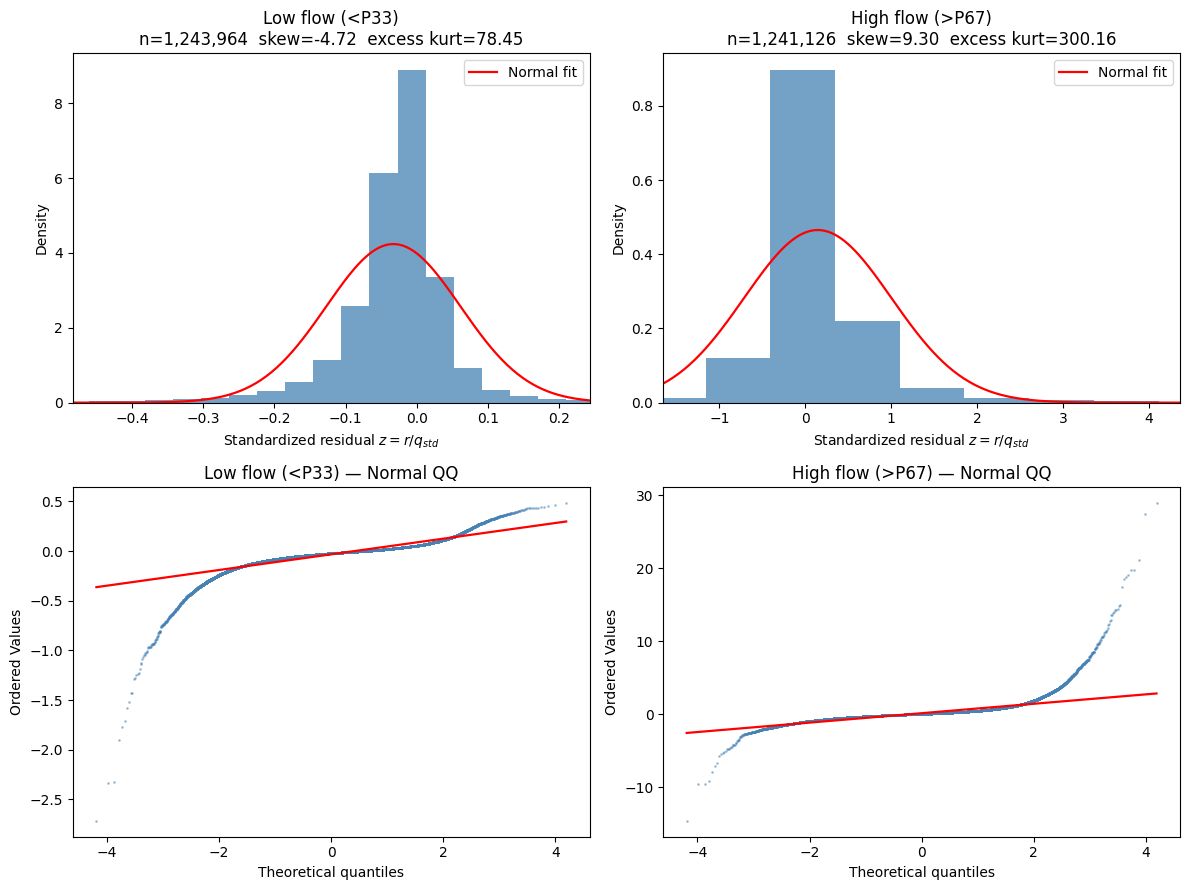

In [14]:
# Cell 10: Residual distributions + Normal QQ, split by flow regime
# Standardize per basin by q_std (per-basin obs SD) -> z = r / q_std, matching the head's
# standardized-NLL target (continue.md s4). Pooling RAW residuals across basins would mix
# scales and fake heavy tails; skew/kurtosis are scale-invariant, so z isolates SHAPE.
q_std = obs_mm.std(axis=0)                              # per-basin obs SD (proxy for q_std)
z = resid.div(q_std, axis=1)
pct = obs_mm.rank(pct=True)                             # within-basin flow percentile

zf, pf = z.values.ravel(), pct.values.ravel()
ok = np.isfinite(zf) & np.isfinite(pf)
zok, pok = zf[ok], pf[ok]
regimes = {'Low flow (<P33)': pok < 0.33, 'High flow (>P67)': pok > 0.67}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for j, (name, sel) in enumerate(regimes.items()):
    d = zok[sel]
    sk, ku = stats.skew(d), stats.kurtosis(d)          # Fisher: excess kurtosis (0 = Normal)

    # Histogram + Normal(mean, std) overlay
    ax = axes[0, j]
    clip = np.quantile(d, [0.005, 0.995])
    sns.histplot(d, bins=120, stat='density', color='steelblue', edgecolor=None, ax=ax)
    xs = np.linspace(*clip, 300)
    ax.plot(xs, stats.norm.pdf(xs, d.mean(), d.std()), 'r-', lw=1.6, label='Normal fit')
    ax.set(xlim=tuple(clip), xlabel='Standardized residual $z = r / q_{std}$',
           title=f'{name}\nn={d.size:,}  skew={sk:.2f}  excess kurt={ku:.2f}')
    ax.legend()

    # Normal QQ (subsample for legibility/speed; departures = skew/heavy tails)
    axq = axes[1, j]
    samp = d if d.size <= 50_000 else RNG.choice(d, 50_000, replace=False)
    stats.probplot(samp, dist='norm', plot=axq)
    axq.get_lines()[0].set(marker='.', ms=2, color='steelblue', alpha=0.4)
    axq.get_lines()[1].set(color='r', lw=1.6)
    axq.set_title(f'{name} — Normal QQ')
plt.tight_layout()
plt.show()


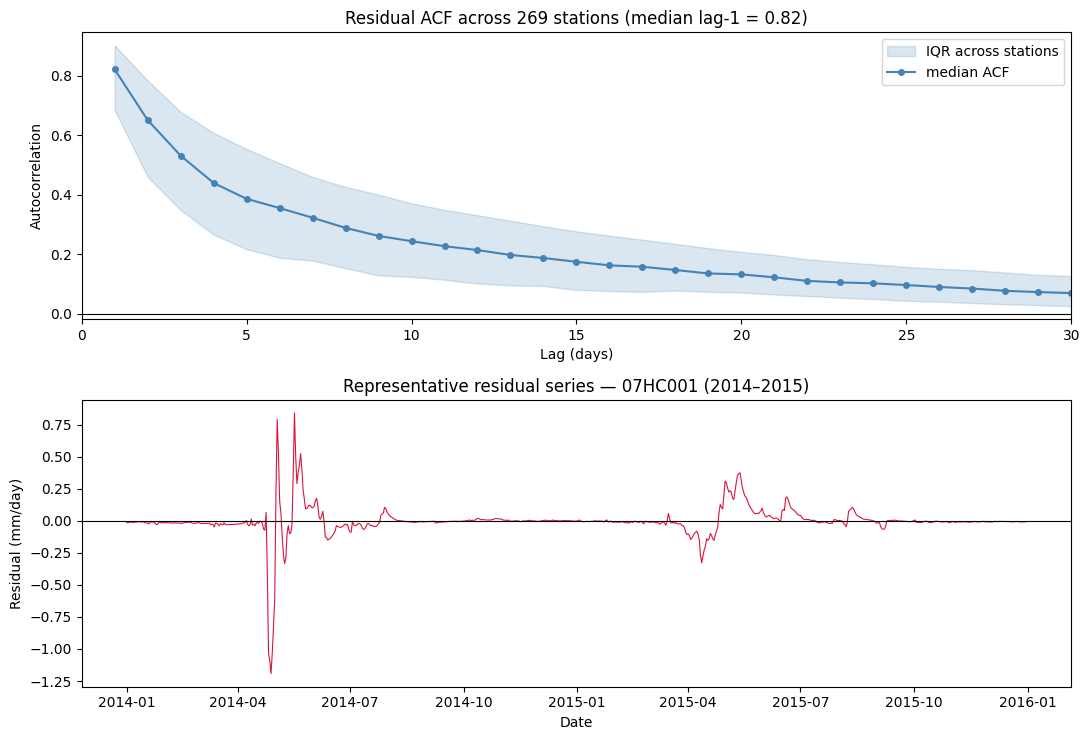

In [15]:
# Cell 11: Residual ACF (across stations) + representative time-series strip
# Per-station ACF (pandas autocorr is NaN-robust pairwise), aggregated across stations.
# Strong lag-1 persistence => residuals are NOT iid; the head's NLL likelihood treats
# them as independent, so effective sample size is inflated (flag for calibration later).
MAX_LAG = 30
lags = np.arange(1, MAX_LAG + 1)
acf_mat = np.full((len(stations), MAX_LAG), np.nan)
for i, s in enumerate(stations):
    series = resid[s]
    if series.notna().sum() < 365:
        continue
    acf_mat[i] = [series.autocorr(lag=int(k)) for k in lags]

acf_med = np.nanmedian(acf_mat, axis=0)
acf_lo, acf_hi = np.nanpercentile(acf_mat, [25, 75], axis=0)
n_ok = int(np.isfinite(acf_mat[:, 0]).sum())

REP = '07HC001'                                        # full obs coverage
strip = resid.loc['2014-01-01':'2015-12-31', REP]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))
ax1.fill_between(lags, acf_lo, acf_hi, alpha=0.2, color='steelblue',
                 label='IQR across stations')
ax1.plot(lags, acf_med, 'o-', color='steelblue', ms=4, label='median ACF')
ax1.axhline(0, color='k', lw=0.8)
ax1.set(xlim=(0, MAX_LAG), xlabel='Lag (days)', ylabel='Autocorrelation',
        title=f'Residual ACF across {n_ok} stations '
              f'(median lag-1 = {acf_med[0]:.2f})')
ax1.legend()

ax2.plot(strip.index, strip.values, color='crimson', lw=0.8)
ax2.axhline(0, color='k', lw=0.8)
ax2.set(xlabel='Date', ylabel='Residual (mm/day)',
        title=f'Representative residual series — {REP} (2014–2015)')
plt.tight_layout()
plt.show()


## OOD Anchoring and Bridge:

### Event hydrographs for the AR and heat-dome windows - Obs vs $\hat\mu$ with ensemble envelope, residual plotted beneath. 
The mean's baseline behavior and bias at the two extremes, which everything in the variance/OOD stage reference. 

## Part 2 - Variance Foundations

Notes about this analysis:

We split the spread around $\hat\mu$ into epistemic (between-member, from the 10 frozen members) and aleatoric (the remainder $\hat\sigma$ will model), identify the structure that remainder takes, and locate it where it matters: tails and the two events. 

Everything is conditioned on the Part 1 bias so $\text{bias}^2$ doesn't leak into the aleatoric term, and carries bootstrap CIs since the remainder is a noisy difference of variances.



## Decomposition: epistemic vs aleatoric

### Between-member variance (epistemic): per-timestep spread of the 10 members
Var across the frozen members at each x — the model uncertainty read straight from the ensemble, no head needed.

### Total vs epistemic: smoothed $(y - \hat\mu)^2$ against between-member variance
Total residual variance = epistemic + aleatoric remainder; the remainder is the head's target and budget. Subtract the Part 1 conditional bias first (smooth with WINDOW, WINDOWS_ROBUST for sensitivity).

### Variance partition by flow percentile: stacked epistemic/aleatoric shares per bin, bootstrap CIs
Mirrors the Part 1 binned-bias figure — which component dominates per regime, and where the remainder is too small to read.

## something else tbd